# Finetuning AlphaGenome on ATAC-seq with linear probing

This notebook demonstrates how to finetune AlphaGenome on GM12878 chromatin accessibility
(ATAC-seq) data using linear probing, where the trunk is frozen and only a new head is trained.

You will need to run this notebook from within a virtual environment with the `dev` dependencies for `alphagenome-pytorch`.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

## 1. Imports

In [2]:
%matplotlib inline

import csv
from datetime import datetime
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.stats import pearsonr
from tqdm import tqdm

from alphagenome_pytorch import AlphaGenome
from alphagenome_pytorch.extensions.finetuning.checkpointing import (
    save_checkpoint,
    load_checkpoint,
)
from alphagenome_pytorch.extensions.finetuning.datasets import (
    CachedGenome,
    GenomicDataset,
    compute_track_means,
)
from alphagenome_pytorch.extensions.finetuning.heads import create_finetuning_head
from alphagenome_pytorch.extensions.finetuning.training import (
    collate_genomic,
    compute_finetuning_loss,
    create_lr_scheduler,
    train_epoch,
    validate,
)
from alphagenome_pytorch.extensions.finetuning.transfer import load_trunk

matplotlib.rcParams['figure.dpi'] = 100
print('Imports OK')

Imports OK


## 2. Configuration

Define hyperparameters and files needed for finetuning. The following hyperparmameters run on an A100.

### Input data:
- `GENOME_FASTA`: A reference genome FASTA file
- `BIGWIG_FILES`: A series of signal BigWig files to train on.
- `TRAIN_BED`: Genomic regions for training. Here, we use regions of size 131,072 base pairs from segments specified in the Borzoi FOLD_0 training set.
- `VAL_BED`: Genomic regions for validation. Here, we use regions of size 131,072 base pairs from segments specified in the Borzoi FOLD_0 validation set.
- `PRETRAINED_WEIGHTS`: Pretrained weights from the AlphaGenome model. We use a conversion from the FOLD_0 model.

### Model settings
- `MODALITY`: Prediction modality.
- `RESOLUTIONS`: Can be `(1,)`, `(128,)`, `(1, 128)`
- `SEQUENCE_LENGTH`: Length of input DNA sequences. We train on 2**17 sequences, can be up to 2\*\*20.

In [3]:
# ── Data paths ────────────────────────────────────────────────────────────────
GENOME_FASTA = 'finetune_files/hg38.fa'
BIGWIG_FILES = ['finetune_files/unstranded.bw']
TRAIN_BED = 'finetune_files/ag_regions/fold_0/train.bed'
VAL_BED = 'finetune_files/ag_regions/fold_0/valid.bed'
PRETRAINED_WEIGHTS = 'finetune_files/weights/fold_0_weights.pth'

# ── Model ─────────────────────────────────────────────────────────────────────
MODALITY = 'atac'
RESOLUTIONS = (1,)  # 1bp only (no 128bp head)
SEQUENCE_LENGTH = 131_072  # 131kb windows

# ── Training Hyperparameters ───────────────────────────────────────────────────
BATCH_SIZE = 4
EPOCHS = 10
LR = 1e-4
WEIGHT_DECAY = 0.1
WARMUP_STEPS = 500
POSITIONAL_WEIGHT = 5.0
NUM_WORKERS = 1
COMPILE = True

# ── Output ────────────────────────────────────────────────────────────────────
run_id = datetime.now().strftime('%Y%m%d_%H%M%S')
OUTPUT_DIR = Path('finetuning_output') / run_id
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Configuration:')
print(f'  MODALITY        : {MODALITY}')
print(f'  RESOLUTIONS     : {RESOLUTIONS}')
print(f'  SEQUENCE_LENGTH : {SEQUENCE_LENGTH:,} bp')
print(f'  BATCH_SIZE      : {BATCH_SIZE}')
print(f'  EPOCHS          : {EPOCHS}')
print(f'  LR              : {LR}')
print(f'  WARMUP_STEPS    : {WARMUP_STEPS}')
print(f'  OUTPUT_DIR      : {OUTPUT_DIR}')
print(f'  COMPILE         : {COMPILE}')

Configuration:
  MODALITY        : atac
  RESOLUTIONS     : (1,)
  SEQUENCE_LENGTH : 131,072 bp
  BATCH_SIZE      : 4
  EPOCHS          : 10
  LR              : 0.0001
  WARMUP_STEPS    : 500
  OUTPUT_DIR      : finetuning_output/20260302_061328
  COMPILE         : True


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
# Resolution weights — all resolutions equally weighted
resolution_weights = {res: 1.0 for res in RESOLUTIONS}
print(f'Resolution weights: {resolution_weights}')

Device: cuda
Resolution weights: {1: 1.0}


## 3. Data Loading

We have 41,694 training and 7,090 validation genomic windows, each 2**17 kb. The BED
file defines windows; `GenomicDataset` expands each interval to exactly `sequence_length` from
its center.

Each sample returns:
- **`sequence`**: one-hot encoded DNA, shape `(131072, 4)`
- **`targets_dict[1]`**: raw ATAC-seq signal at 1bp resolution, shape `(131072, 1)`

`CachedGenome` pre-loads the entire hg38 genome (~12 GB) into RAM as one-hot arrays.
Pass the same `CachedGenome` instance to both datasets to share the cache and halve memory usage.

In [5]:
print('Loading genome into memory (hg38, ~12 GB)...')
print('  (This takes 3-5 minutes on first run)')
shared_genome = CachedGenome(GENOME_FASTA)

print('\nCreating train/val datasets...')
# Pass the CachedGenome directly as genome_fasta to share the cache
train_dataset = GenomicDataset(
    genome_fasta=shared_genome,
    bigwig_files=BIGWIG_FILES,
    bed_file=TRAIN_BED,
    resolutions=RESOLUTIONS,
    sequence_length=SEQUENCE_LENGTH,
)
val_dataset = GenomicDataset(
    genome_fasta=shared_genome,
    bigwig_files=BIGWIG_FILES,
    bed_file=VAL_BED,
    resolutions=RESOLUTIONS,
    sequence_length=SEQUENCE_LENGTH,
)
print(f'\nTrain: {len(train_dataset):,}  Val: {len(val_dataset):,}')

Loading genome into memory (hg38, ~12 GB)...
  (This takes 3-5 minutes on first run)
CachedGenome: Loading genome from finetune_files/hg38.fa...
CachedGenome: Loaded 455 chromosomes (12837.1 MB)

Creating train/val datasets...

Train: 41,694  Val: 6,461


/scratch/m000097/abuen/personal/alphagenome-pytorch/src/alphagenome_pytorch/extensions/finetuning/datasets.py:547: UserWarning: 41694 intervals were larger than sequence_length=131072 and were centered and truncated, which may lose important flanking regions.
  warnings.warn(
/scratch/m000097/abuen/personal/alphagenome-pytorch/src/alphagenome_pytorch/extensions/finetuning/datasets.py:547: UserWarning: 6461 intervals were larger than sequence_length=131072 and were centered and truncated, which may lose important flanking regions.
  warnings.warn(


In [6]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=collate_genomic,
    prefetch_factor=2 if NUM_WORKERS > 0 else None,
    persistent_workers=NUM_WORKERS > 0,
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=collate_genomic,
    prefetch_factor=2 if NUM_WORKERS > 0 else None,
    persistent_workers=NUM_WORKERS > 0,
)

print(f'Train loader: {len(train_loader):,} batches/epoch')
print(f'Val loader  : {len(val_loader):,} batches')

Train loader: 10,424 batches/epoch
Val loader  : 1,616 batches


## 4. Model Setup

In [7]:
print(f'Loading pretrained AlphaGenome weights from {PRETRAINED_WEIGHTS}...')
model = AlphaGenome()
model = load_trunk(model, PRETRAINED_WEIGHTS, exclude_heads=True)

# Freeze backbone — only the new head will be trained
for param in model.parameters():
    param.requires_grad = False

n_backbone = sum(p.numel() for p in model.parameters())
print(f'Backbone frozen.')
print(f'  Backbone parameters: {n_backbone:,}')

Loading pretrained AlphaGenome weights from finetune_files/weights/fold_0_weights.pth...
Backbone frozen.
  Backbone parameters: 450,452,613


In [8]:
print('Computing track means from training data...')
track_means = compute_track_means(
    BIGWIG_FILES,
    TRAIN_BED,
    sequence_length=SEQUENCE_LENGTH,
    max_samples=1000,
)

# Create finetuning head and attach to model
head = create_finetuning_head(
    assay_type=MODALITY,
    n_tracks=len(BIGWIG_FILES),
    resolutions=RESOLUTIONS,
    num_organisms=1,
    track_means=track_means,
)
model.heads[MODALITY] = head
model = model.to(device)
head = model.heads[MODALITY]  # update reference after .to()

if COMPILE:
    print("Compiling model (first run will be slow)...")
    model = torch.compile(model)

n_trainable = sum(p.numel() for p in head.parameters())
n_total = sum(p.numel() for p in model.parameters())
print(f'\nTrainable: {n_trainable:,} / {n_total:,} ({100 * n_trainable / n_total:.4f}%)')

Computing track means from training data...
Computed nonzero_mean per track: [2.24096773]
Compiling model (first run will be slow)...

Trainable: 1,538 / 448,092,807 (0.0003%)


## 5. Training Setup

In [9]:
optimizer = torch.optim.AdamW(
    head.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

steps_per_epoch = len(train_loader)
total_steps = EPOCHS * steps_per_epoch
scheduler = create_lr_scheduler(optimizer, WARMUP_STEPS, total_steps, schedule='cosine')

AlphaGenome uses a loss with two parts:

1. **Positional (multinomial) loss** (`loss_positional`). Upweighted by `positional_weight=5.0`.
2. **Count (Poisson) loss** (`loss_count`).

The multinomial loss is computed across `NUM_SEGMENTS=8` equal segments for numerical stability.
The sequence length (131,072 bp) is divided into 8 segments of 16,384 bp each.

We use `compute_finetuning_loss` from the library, which handles this internally.
The library also provides `train_epoch` and `validate` functions that implement the full
training loop with gradient accumulation, AMP, and progress bars.

## 6. Training Loop

In [ ]:
epoch_log_rows = []
best_val_loss = float('inf')

print(f'Starting training: {EPOCHS} epochs, batch size {BATCH_SIZE}')
print(f'Outputs → {OUTPUT_DIR}')
print('=' * 60)

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(
        model=model,
        head=head,
        train_loader=train_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        resolution_weights=resolution_weights,
        positional_weight=POSITIONAL_WEIGHT,
        epoch=epoch,
        log_every=50,
    )

    val_loss = validate(
        model=model,
        head=head,
        val_loader=val_loader,
        device=device,
        resolution_weights=resolution_weights,
        positional_weight=POSITIONAL_WEIGHT,
    )

    current_lr = scheduler.get_last_lr()[0]
    is_best = val_loss < best_val_loss

    star = '★ best' if is_best else ''
    print(f'\nEpoch {epoch:2d} | train={train_loss:.4f}  val={val_loss:.4f}'
          f'  lr={current_lr:.2e}  {star}')

    epoch_row = {
        'epoch': epoch,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'learning_rate': current_lr,
        'is_best': is_best,
        'timestamp': datetime.now().isoformat(),
    }
    epoch_log_rows.append(epoch_row)

    if is_best:
        best_val_loss = val_loss
        save_checkpoint(
            path=OUTPUT_DIR / 'best_model.pth',
            epoch=epoch,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            val_loss=val_loss,
            best_val_loss=best_val_loss,
            track_names=[Path(BIGWIG_FILES[0]).stem],
            modality=MODALITY,
            resolutions=RESOLUTIONS,
        )
        print(f'  -> Best model saved (val={val_loss:.4f})')

    save_checkpoint(
        path=OUTPUT_DIR / f'checkpoint_epoch{epoch}.pth',
        epoch=epoch,
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        val_loss=val_loss,
        best_val_loss=best_val_loss,
        track_names=[Path(BIGWIG_FILES[0]).stem],
        modality=MODALITY,
        resolutions=RESOLUTIONS,
    )

# ── Write CSV ──────────────────────────────────────────────────────────────────
with open(OUTPUT_DIR / 'epoch_log.csv', 'w', newline='') as f:
    if epoch_log_rows:
        writer = csv.DictWriter(f, fieldnames=list(epoch_log_rows[0].keys()))
        writer.writeheader()
        writer.writerows(epoch_log_rows)

print(f'\n{"="*60}')
print(f'Training complete!')
print(f'Best val loss : {best_val_loss:.4f}')
print(f'Output        : {OUTPUT_DIR}')

## 7. Results Visualization

Training converged quickly over 10 epochs:

- **Loss decomposition**: the total multinomial loss is dominated by the positional
  component, meaning peak shape is the harder prediction task. The count component is small — predicting total read depth from sequence is easier.
- **Train/val gap**: minimal, indicating no significant overfitting despite only 1,538 trained parameters.

In [10]:
# uncomment for demo run results
# OUTPUT_DIR = Path('finetuning_output') / "20260301_153530"

=== Training Summary ===
Epochs completed  : 10
Best val loss     : 7.722594  (epoch 6)
Final train loss  : 7.982453
Final val loss    : 7.722741


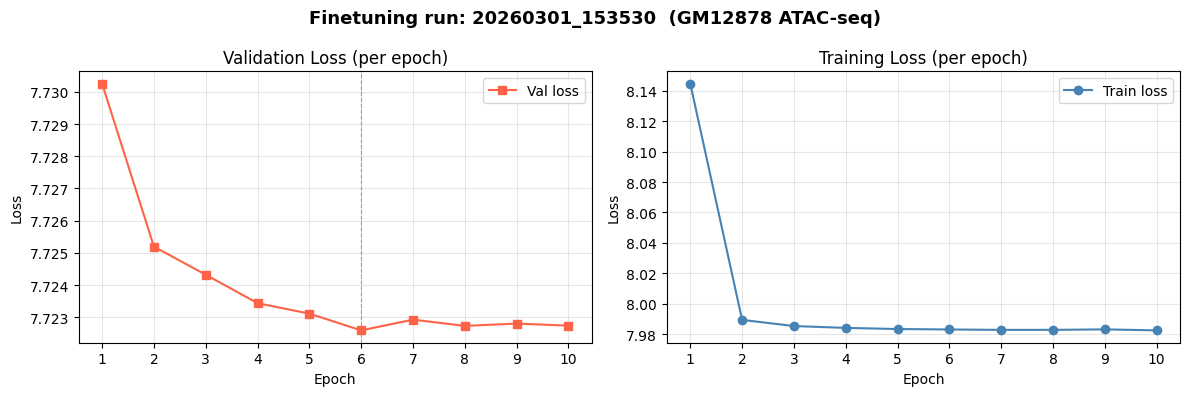

In [11]:
epoch_df = pd.read_csv(OUTPUT_DIR / 'epoch_log.csv')

best_row = epoch_df.loc[epoch_df['val_loss'].idxmin()]
final_row = epoch_df.iloc[-1]

print('=== Training Summary ===')
print(f'Epochs completed  : {len(epoch_df)}')
print(f'Best val loss     : {best_row["val_loss"]:.6f}  (epoch {int(best_row["epoch"])})')
print(f'Final train loss  : {final_row["train_loss"]:.6f}')
print(f'Final val loss    : {final_row["val_loss"]:.6f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(
    f'Finetuning run: {OUTPUT_DIR.name}  (GM12878 ATAC-seq)',
    fontsize=13, fontweight='bold'
)

# ── Val loss per epoch ─────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(epoch_df['epoch'], epoch_df['val_loss'], marker='s', color='tomato', label='Val loss')
ax.axvline(int(best_row['epoch']), color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Validation Loss (per epoch)'); ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xticks(epoch_df['epoch'])

# ── Train loss per epoch ───────────────────────────────────────────────────────
ax = axes[1]
ax.plot(epoch_df['epoch'], epoch_df['train_loss'], marker='o', color='steelblue', label='Train loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Training Loss (per epoch)'); ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xticks(epoch_df['epoch'])

plt.tight_layout()
plt.show()

In [12]:
display_cols = ['epoch', 'train_loss', 'val_loss', 'learning_rate', 'is_best']

print('Epoch-level summary:')
epoch_df[display_cols].round(6)

Epoch-level summary:


,epoch,train_loss,val_loss,learning_rate,is_best
0,1,8.144648,7.730252,0.000098,True
1,2,7.989362,7.725195,0.000091,True
2,3,7.985308,7.724322,0.000080,True
3,4,7.984085,7.723439,0.000066,True
4,5,7.983350,7.723115,0.000050,True
5,6,7.983046,7.722594,0.000035,True
6,7,7.982787,7.722927,0.000021,False
7,8,7.982798,7.722734,0.000010,False
8,9,7.983119,7.722805,0.000002,False
9,10,7.982453,7.722741,0.000000,False


## 8. Evaluation: Comparing Fine-tuned to Baseline

In [13]:
# Create a fresh head with the same architecture but random (untrained) weights
baseline_head = create_finetuning_head(
    assay_type=MODALITY,
    n_tracks=len(BIGWIG_FILES),
    resolutions=RESOLUTIONS,
    num_organisms=1,
    track_means=track_means,
).to(device)
baseline_head.eval()

n_baseline = sum(p.numel() for p in baseline_head.parameters())
print('Baseline (untrained) head created.')
print(f'  Parameters : {n_baseline:,}  (randomly initialized, no training)')

Baseline (untrained) head created.
  Parameters : 1,538  (randomly initialized, no training)


In [14]:
# Retrieve a validation sample for the predicted vs. fine-tuned set
VAL_IDX = 0
val_seq, val_targets = val_dataset[VAL_IDX]
seq_input = val_seq.unsqueeze(0).to(device)  # (1, 131072, 4)
organism_idx = torch.zeros(1, dtype=torch.long, device=device)

# Compute the backbone embeddings using return_embeddings=True
model.eval()
with torch.no_grad():
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16,
                        enabled=device.type == 'cuda'):
        outputs = model(
            seq_input, organism_idx,
            return_embeddings=True,
        )

embeddings_dict = {}
if 1 in RESOLUTIONS and outputs.get('embeddings_1bp') is not None:
    embeddings_dict[1] = outputs['embeddings_1bp']
if 128 in RESOLUTIONS and outputs.get('embeddings_128bp') is not None:
    embeddings_dict[128] = outputs['embeddings_128bp']

print(f'Backbone embeddings computed for val sample {VAL_IDX}:')
for res, emb in embeddings_dict.items():
    print(f'  embeddings_{res}bp : {tuple(emb.shape)}')

# Baseline predictions (untrained head)
with torch.no_grad():
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16,
                        enabled=device.type == 'cuda'):
        baseline_preds = baseline_head(embeddings_dict, organism_idx)

# Load best checkpoint and get fine-tuned predictions
best_ckpt_path = OUTPUT_DIR / 'best_model.pth'
print(f'Loading best model from {best_ckpt_path}...')
load_checkpoint(
    path=best_ckpt_path,
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
)
model.eval()
head.eval()

with torch.no_grad():
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16,
                        enabled=device.type == 'cuda'):
        finetuned_preds = head(embeddings_dict, organism_idx)

Backbone embeddings computed for val sample 0:
  embeddings_1bp : (1, 131072, 1536)
Loading best model from finetuning_output/20260301_153530/best_model.pth...


In [15]:
# Run inference on pretrained model to get GM12878 predictions
from alphagenome.models import dna_output
from alphagenome_research.model import dna_model as ag_dna_model
from alphagenome_research.model.metadata import metadata as metadata_lib

ATAC_ONTOLOGY_CURIE = 'EFO:0002784'  # GM12878
metadata = metadata_lib.load(ag_dna_model.Organism.HOMO_SAPIENS)
track_masks = metadata_lib.create_track_masks(
    metadata,
    requested_outputs={dna_output.OutputType.ATAC},
    requested_ontologies=[dna_output.ontology.from_curie(ATAC_ONTOLOGY_CURIE)],
)
atac_mask = track_masks[dna_output.OutputType.ATAC]
gm12878_track_indices = np.flatnonzero(atac_mask)
ATAC_GM12878_TRACK_IDX = int(gm12878_track_indices[0])

print('Running pretrained model inference for GM12878 ATAC track...')
pretrained_model = AlphaGenome()
pretrained_model = load_trunk(pretrained_model, PRETRAINED_WEIGHTS, exclude_heads=False)
pretrained_model = pretrained_model.to(device)
pretrained_model.eval()

with torch.no_grad():
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=device.type == 'cuda'):
        pretrained_outputs = pretrained_model(
            seq_input,
            organism_idx,
            resolutions=(1,),
        )
pretrained_atac_gm12878 = pretrained_outputs['atac'][1][:, :, ATAC_GM12878_TRACK_IDX:ATAC_GM12878_TRACK_IDX + 1]

Running pretrained model inference for GM12878 ATAC track...


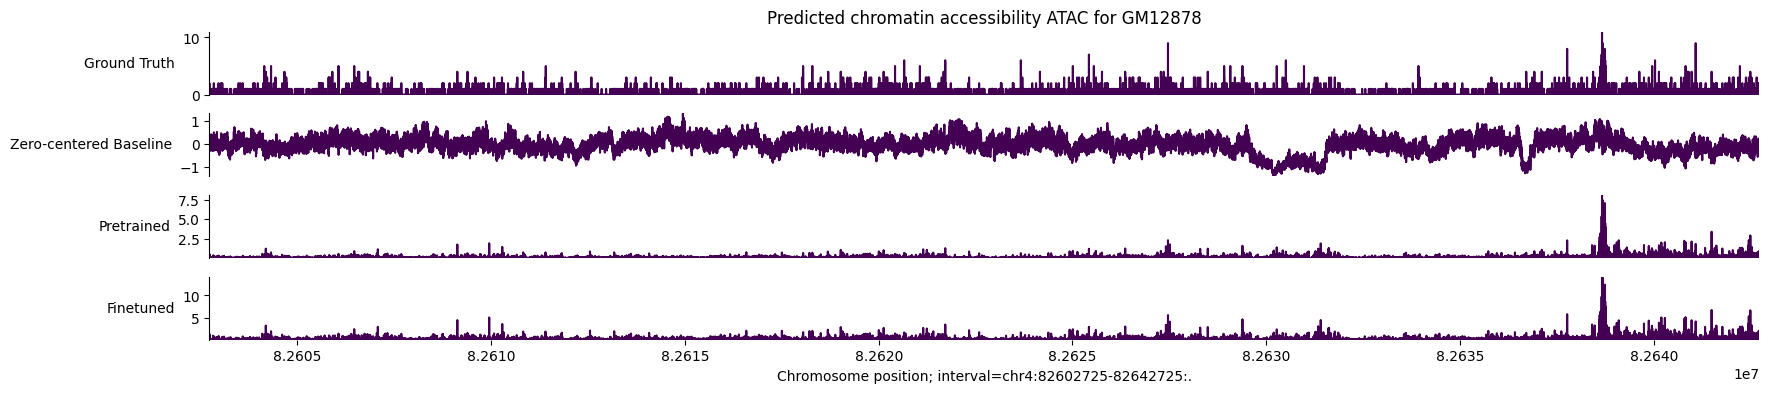

In [16]:
# Visualize the differences between ground truth, finetuned, baseline, and pretrained
from alphagenome.visualization import plot_components
from alphagenome.data import genome as jax_genome
from alphagenome_pytorch.variant_scoring.visualization_utils import pytorch_to_track_data

chrom, start, end = val_dataset._positions_list[VAL_IDX]
jax_interval = jax_genome.Interval(chromosome=chrom, start=start, end=end)

track_meta = type('M', (), {
    'track_name': 'GM12878 ATAC-seq',
    'track_strand': '.',
    'biosample_name': 'GM12878',
    'ontology_curie': 'EFO:0002784',
    'assay_title': 'ATAC-seq',
    'transcription_factor': '',
    'histone_mark': '',
})()
metadata_list = [track_meta]

gt_tdata = pytorch_to_track_data(val_targets[1], metadata_list, jax_interval, resolution=1)
bl_tdata = pytorch_to_track_data(baseline_preds[1] - baseline_preds[1].mean(), metadata_list, jax_interval, resolution=1)  # Zero center
ft_tdata = pytorch_to_track_data(finetuned_preds[1], metadata_list, jax_interval, resolution=1)
pt_tdata = pytorch_to_track_data(pretrained_atac_gm12878, metadata_list, jax_interval, resolution=1)

components = [
    plot_components.Tracks(
        tdata=gt_tdata,
        ylabel_template='Ground Truth',
    ),
    plot_components.Tracks(
        tdata=bl_tdata,
        ylabel_template='Zero-centered Baseline',
    ),
    plot_components.Tracks(
        tdata=pt_tdata,
        ylabel_template='Pretrained',
    ),
    plot_components.Tracks(
        tdata=ft_tdata,
        ylabel_template='Finetuned',
    ),
]

plot_interval = jax_interval.resize(40000)

plot_components.plot(
    components=components,
    interval=plot_interval,
    title='Predicted chromatin accessibility ATAC for GM12878',
);

In [17]:
# ── Pearson correlation ────────────────────────────────────────────────────────
BIN = 128
n_bins = SEQUENCE_LENGTH // BIN

# Bin to 128bp for comparison
ft_1bp_tensor = finetuned_preds[1][0, :, 0].float().cpu()
ft_binned = ft_1bp_tensor.numpy()[:n_bins * BIN].reshape(n_bins, BIN).mean(axis=1)

gt_1bp_tensor = val_targets[1][:, 0].float().cpu()
gt_binned = gt_1bp_tensor.numpy()[:n_bins * BIN].reshape(n_bins, BIN).mean(axis=1)

bl_1bp_tensor = baseline_preds[1][0, :, 0].float().cpu()
bl_binned = bl_1bp_tensor.numpy()[:n_bins * BIN].reshape(n_bins, BIN).mean(axis=1)

pt_1bp_tensor = pretrained_atac_gm12878[0, :, 0].float().cpu()
pt_binned = pt_1bp_tensor.numpy()[:n_bins * BIN].reshape(n_bins, BIN).mean(axis=1)

r_finetuned, _ = pearsonr(gt_binned, ft_binned)
r_baseline, _ = pearsonr(gt_binned, bl_binned)
r_pretrained, _ = pearsonr(gt_binned, pt_binned)

print('=' * 50)
print('Pearson r (ground truth vs untrained baseline):')
print(f'  r = {r_baseline:.4f}')

print('Pearson r (ground truth vs pretrained model):')
print(f'  r = {r_pretrained:.4f}')

print('Pearson r (ground truth vs finetuned head):')
print(f'  r = {r_finetuned:.4f}')

print(f'Improvement (finetuned - baseline): {r_finetuned - r_baseline:+.4f}')
print(f'Improvement (finetuned - pretrained): {r_finetuned - r_pretrained:+.4f}')
print('=' * 50)

Pearson r (ground truth vs untrained baseline):
  r = -0.1696
Pearson r (ground truth vs pretrained model):
  r = 0.5890
Pearson r (ground truth vs finetuned head):
  r = 0.6228
Improvement (finetuned - baseline): +0.7924
Improvement (finetuned - pretrained): +0.0337
